[&#8592; Previous: Loading Data](01_loading_data.ipynb)

In [10]:
import pandas as pd
import numpy as np
from pathlib import Path

RAW_DATA = Path("../data/raw")  # use Path("data/raw") if running from project root

mips = pd.read_csv(RAW_DATA / "grp_public_reporting.csv", dtype=str)
dac = pd.read_csv(RAW_DATA / "DAC_NationalDownloadableFile.csv", dtype=str)

mips.columns = mips.columns.str.strip()
dac.columns = dac.columns.str.strip()

mips["org_pac_id"] = (
    mips["org_PAC_ID"].astype("string").str.strip().str.zfill(10)
)

dac["org_pac_id"] = (
    dac["org_pac_id"].astype("string").str.strip().str.zfill(10)
)

In [11]:
print(mips["org_pac_id"].dropna().str.strip().str.len().value_counts())
print(dac["org_pac_id"].dropna().str.strip().str.len().value_counts())

org_pac_id
10    199228
Name: count, dtype: Int64
org_pac_id
10    3043125
Name: count, dtype: Int64


In [12]:
zip_county = pd.read_csv(RAW_DATA / "ZIP-COUNTY.csv", dtype=str)

# Clean column names because MIPS has leading spaces
zip_county.columns = zip_county.columns.str.strip()

zip_county

,zip,geoid,res_ratio,bus_ratio,oth_ratio,tot_ratio,city,state
0,00501,36103,0.000000000,1.000000000,0.000000000,1.000000000,HOLTSVILLE,NY
1,00601,72001,0.997451580,0.994936709,0.987951807,0.997052893,ADJUNTAS,PR
2,00601,72081,0.002548420,0.005063291,0.012048193,0.002947107,ADJUNTAS,PR
3,00602,72003,0.999416278,0.998983740,1.000000000,0.999394856,AGUADA,PR
4,00602,72117,0.000583722,0.000000000,0.000000000,0.000529501,AGUADA,PR
...,...,...,...,...,...,...,...,...
54557,99926,02198,1.000000000,0.000000000,1.000000000,1.000000000,METLAKATLA,AK
54558,99927,02198,0.000000000,0.000000000,1.000000000,1.000000000,POINT BAKER,AK
54559,99928,02130,0.000000000,0.000000000,1.000000000,1.000000000,WARD COVE,AK
54560,99929,02275,1.000000000,1.000000000,1.000000000,1.000000000,WRANGELL,AK


In [13]:
len(zip_county['zip']), len(zip_county['geoid'])

(54562, 54562)

In [14]:
def clean_zip5(x):
    if pd.isna(x):
        return pd.NA
    
    x = str(x).strip()
    
    # Remove decimal artifact 
    if x.endswith(".0"):
        x = x[:-2]
    
    # Keep only digits
    digits = "".join(ch for ch in x if ch.isdigit())
    
    if len(digits) == 0:
        return pd.NA
    
    # ensure 5 digits with leading zeros if necessary
    return digits[:5].zfill(5)

dac["zip5"] = dac["ZIP Code"].apply(clean_zip5)

dac[["org_pac_id", "ZIP Code", "zip5"]].head()

,org_pac_id,ZIP Code,zip5
0,<NA>,00602,00602
1,<NA>,00602,00602
2,<NA>,00603,00603
3,<NA>,00622,00622
4,<NA>,00646,00646


In [15]:
# Clean org_pac_id column in dac, remove na values (individual physicians have no org_pac_id)

dac["org_pac_id"] = dac["org_pac_id"].astype("string").str.strip()

dac_group = dac[
    dac["org_pac_id"].notna() &
    dac["org_pac_id"].ne("") &
    dac["org_pac_id"].str.lower().ne("nan")
].copy()

dac_group[["org_pac_id", "ZIP Code", "zip5"]].head()

,org_pac_id,ZIP Code,zip5
5,6305731118,00646,00646
16,0042383200,00791,00791
17,1254311137,00791,00791
18,9638151756,00802,00802
19,2860304482,00840,00840


In [17]:
# Keep only valid, unique organization-location keys
dac_group = (
    dac.loc[
        dac["org_pac_id"].notna()
        & dac["zip5"].notna(),
        ["org_pac_id", "zip5"]
    ]
    .drop_duplicates()
    .copy()
)

print("DAC rows:", len(dac))
print("Unique organization-ZIP rows:", len(dac_group))

DAC rows: 3387942
Unique organization-ZIP rows: 227313


In [18]:
mips_slim = mips[
    [
        "org_pac_id",
        "Facility Name",
        "measure_cd",
        "measure_title",
        "invs_msr",
        "prf_rate",
        "patient_count",
        "star_value",
        "five_star_benchmark",
        "collection_type",
    ]
].copy()

duplicate_key = [
    "org_pac_id",
    "measure_cd",
    "collection_type",
]

print(
    mips_slim.duplicated(
        subset=duplicate_key,
        keep=False,
    ).sum()
)

0


In [19]:
#merge mips and dac_group on org_pac_id
#merged = pd.merge(mips, dac_group, on="org_pac_id", how="left", suffixes=("_mips", "_dac"))
merged = mips_slim.merge(
    dac_group,
    on="org_pac_id",
    how="left",
    validate="many_to_many",
)


In [20]:
missing_zip_pct=merged['zip5'].isna().sum()/len(merged)*100
print(f"{missing_zip_pct:.2f}% of rows are missing zip5")

2.27% of rows are missing zip5


In [21]:
merged_no_missing_zip = merged.dropna(subset=["zip5"])

In [22]:


# ZIP-to-county crosswalk
# Standardize join keys
zip_county["zip5"] = zip_county["zip"].astype(str).str.zfill(5)
zip_county["county_fips"] = zip_county["geoid"].astype(str).str.zfill(5)

merged_no_missing_zip["zip5"] = merged_no_missing_zip["zip5"].astype(str).str.zfill(5)

# Merge MIPS/DAC ZIP data to county crosswalk
mips_zip_county = merged_no_missing_zip.merge(
    zip_county[["zip5", "county_fips", "tot_ratio", "res_ratio", "city", "state"]],
    on="zip5",
    how="left"
)

# Check ZIP-to-county match rate
print("Missing county_fips after ZIP-county merge:")
print(mips_zip_county["county_fips"].isna().mean() * 100)

C:\Users\zslet\AppData\Local\Temp\ipykernel_22780\278393885.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_no_missing_zip["zip5"] = merged_no_missing_zip["zip5"].astype(str).str.zfill(5)


Missing county_fips after ZIP-county merge:
0.053861658100347806


In [25]:

geo = pd.read_csv(
    RAW_DATA / "2014-2024 Original Medicare Geographic Variation Public Use File.csv",
    dtype=str
)

geo.columns = geo.columns.str.strip()

# Standardize county FIPS in geo
geo["county_fips"] = geo["BENE_GEO_CD"].astype(str).str.zfill(5)

print(geo["BENE_GEO_LVL"].value_counts(dropna=False))
print(geo["BENE_AGE_LVL"].value_counts(dropna=False))
print(geo["YEAR"].value_counts(dropna=False).sort_index())

BENE_GEO_LVL
County      35146
State        1815
National       33
Name: count, dtype: int64
BENE_AGE_LVL
All     35762
<65       616
>=65      616
Name: count, dtype: int64
YEAR
2014    3362
2015    3363
2016    3362
2017    3362
2018    3362
2019    3362
2020    3362
2021    3364
2022    3365
2023    3365
2024    3365
Name: count, dtype: int64


In [26]:
geo_county = geo[
    geo["BENE_GEO_LVL"].str.lower().eq("county")
].copy()

In [27]:

# 1. Standardize ZIP-county crosswalk keys
zip_county.columns = zip_county.columns.str.strip()

zip_county["zip5"] = zip_county["zip"].astype("string").str.zfill(5)
zip_county["county_fips"] = zip_county["geoid"].astype("string").str.zfill(5)

zip_county["tot_ratio"] = pd.to_numeric(zip_county["tot_ratio"], errors="coerce")
zip_county["res_ratio"] = pd.to_numeric(zip_county["res_ratio"], errors="coerce")

# 2. Standardize ZIP in merged MIPS/DAC file
merged_no_missing_zip = merged_no_missing_zip.copy()
merged_no_missing_zip["zip5"] = merged_no_missing_zip["zip5"].astype("string").str.zfill(5)

# 3. Merge MIPS/DAC ZIP rows to county FIPS using ZIP-county crosswalk
mips_zip_county = merged_no_missing_zip.merge(
    zip_county[["zip5", "county_fips", "tot_ratio", "res_ratio", "city", "state"]],
    on="zip5",
    how="left"
)

print("Missing county_fips after ZIP-county merge:")
print(f"{mips_zip_county['county_fips'].isna().mean() * 100:.2f}%")

# 4. Convert MIPS performance rate to numeric
mips_zip_county["prf_rate"] = pd.to_numeric(
    mips_zip_county["prf_rate"],
    errors="coerce"
)

# 5. Aggregate MIPS performance to county level
# Using tot_ratio to allocate ZIPs that span multiple counties
mips_county = (
    mips_zip_county
    .dropna(subset=["county_fips", "prf_rate", "tot_ratio"])
    .assign(weighted_prf_rate=lambda x: x["prf_rate"] * x["tot_ratio"])
    .groupby("county_fips", as_index=False)
    .agg(
        weighted_prf_rate_sum=("weighted_prf_rate", "sum"),
        weight_sum=("tot_ratio", "sum"),
        avg_prf_rate_unweighted=("prf_rate", "mean"),
        groups_count=("org_pac_id", "nunique"),
        mips_rows=("prf_rate", "size")
    )
)

mips_county["avg_prf_rate_weighted"] = (
    mips_county["weighted_prf_rate_sum"] / mips_county["weight_sum"]
)

# 6. Standardize county FIPS in geo_county
geo_county = geo_county.copy()

geo_county["county_fips"] = (
    geo_county["BENE_GEO_CD"]
    .where(geo_county["BENE_GEO_CD"].notna())
    .astype("string")
    .str.zfill(5)
)

# 7. Final county-level analytic dataset
analytic = geo_county.merge(
    mips_county,
    on="county_fips",
    how="left"
)

# 8. QA checks
print("MIPS/DAC ZIP rows:", len(merged_no_missing_zip))
print("MIPS ZIP-county rows:", len(mips_zip_county))
print("County-level MIPS rows:", len(mips_county))
print("Geo county rows:", len(geo_county))
print("Final analytic rows:", len(analytic))
print("Counties with MIPS data:", analytic["avg_prf_rate_weighted"].notna().sum())
print("Missing MIPS % in analytic:")
print(f"{analytic['avg_prf_rate_weighted'].isna().mean() * 100:.2f}%")

analytic.head()

Missing county_fips after ZIP-county merge:
0.05%
MIPS/DAC ZIP rows: 1100362
MIPS ZIP-county rows: 1526132
County-level MIPS rows: 2977
Geo county rows: 35146
Final analytic rows: 35146
Counties with MIPS data: 32426
Missing MIPS % in analytic:
7.74%


,YEAR,BENE_GEO_LVL,BENE_GEO_DESC,BENE_GEO_CD,BENE_AGE_LVL,BENES_TOTAL_CNT,BENES_WTH_PTAPTB_CNT,BENES_OM_CNT,BENES_MA_CNT,MA_PRTCPTN_RATE,...,PQI16_LWRXTRMTY_AMPUTN_AGE_LT_65,PQI16_LWRXTRMTY_AMPUTN_AGE_65_74,PQI16_LWRXTRMTY_AMPUTN_AGE_GE_75,county_fips,weighted_prf_rate_sum,weight_sum,avg_prf_rate_unweighted,groups_count,mips_rows,avg_prf_rate_weighted
0,2014,County,AK-Aleutians East,02013,All,168,*,117,*,*,...,NaN,NaN,NaN,02013,NaN,NaN,NaN,NaN,NaN,NaN
1,2014,County,AK-Aleutians West,02016,All,231,136,136,0,0,...,NaN,NaN,NaN,02016,540.000,8.0,67.500000,1.0,8.0,67.500000
2,2014,County,AK-Anchorage,02020,All,33247,27755,27578,177,0.0064,...,NaN,NaN,NaN,02020,53192.533,1018.0,52.251997,49.0,1018.0,52.251997
3,2014,County,AK-Bethel,02050,All,1311,*,1059,*,*,...,NaN,NaN,NaN,02050,NaN,NaN,NaN,NaN,NaN,NaN
4,2014,County,AK-Bristol Bay,02060,All,122,104,104,0,0,...,NaN,NaN,NaN,02060,540.000,8.0,67.500000,1.0,8.0,67.500000


In [28]:
analytic.columns

Index(['YEAR', 'BENE_GEO_LVL', 'BENE_GEO_DESC', 'BENE_GEO_CD', 'BENE_AGE_LVL',
       'BENES_TOTAL_CNT', 'BENES_WTH_PTAPTB_CNT', 'BENES_OM_CNT',
       'BENES_MA_CNT', 'MA_PRTCPTN_RATE',
       ...
       'PQI16_LWRXTRMTY_AMPUTN_AGE_LT_65', 'PQI16_LWRXTRMTY_AMPUTN_AGE_65_74',
       'PQI16_LWRXTRMTY_AMPUTN_AGE_GE_75', 'county_fips',
       'weighted_prf_rate_sum', 'weight_sum', 'avg_prf_rate_unweighted',
       'groups_count', 'mips_rows', 'avg_prf_rate_weighted'],
      dtype='object', length=253)

In [29]:
mips_zip_county["prf_rate"] = pd.to_numeric(mips_zip_county["prf_rate"], errors="coerce")
mips_zip_county["tot_ratio"] = pd.to_numeric(mips_zip_county["tot_ratio"], errors="coerce")

mips_county_measure = (
    mips_zip_county
    .dropna(subset=["county_fips", "measure_cd", "prf_rate", "tot_ratio"])
    .assign(weighted_prf_rate=lambda x: x["prf_rate"] * x["tot_ratio"])
    .groupby(["county_fips", "measure_cd", "measure_title"], as_index=False)
    .agg(
        weighted_prf_rate_sum=("weighted_prf_rate", "sum"),
        weight_sum=("tot_ratio", "sum"),
        avg_prf_rate_unweighted=("prf_rate", "mean"),
        groups_count=("org_pac_id", "nunique"),
        mips_rows=("prf_rate", "size")
    )
)

mips_county_measure["avg_prf_rate_weighted"] = (
    mips_county_measure["weighted_prf_rate_sum"] / mips_county_measure["weight_sum"]
)


analytic_measure = geo_county.merge(
    mips_county_measure,
    on="county_fips",
    how="left"
)

In [30]:
analytic_measure[
    analytic_measure["BENE_GEO_DESC"].str.contains("Washtenaw", case=False, na=False)
][["YEAR", "BENE_GEO_DESC", "county_fips"]].drop_duplicates().head(20)

,YEAR,BENE_GEO_DESC,county_fips
62655,2014,MI-Washtenaw,26161
208836,2015,MI-Washtenaw,26161
355016,2016,MI-Washtenaw,26161
501196,2017,MI-Washtenaw,26161
647376,2018,MI-Washtenaw,26161
793556,2019,MI-Washtenaw,26161
939736,2020,MI-Washtenaw,26161
1085940,2021,MI-Washtenaw,26161
1233136,2022,MI-Washtenaw,26161
1380332,2023,MI-Washtenaw,26161


In [31]:
analytic_measure[
    analytic_measure["measure_cd"].astype(str).str.contains("130", case=False, na=False)
][["measure_cd", "measure_title"]].drop_duplicates().head(20)

,measure_cd,measure_title
27,MIPS_GRP_130_overall,Documentation of Current Medications in the Me...


In [32]:
analytic_measure["measure_cd"].dropna().sort_values().unique()[:50]

array(['MIPS_GRP_001_overall', 'MIPS_GRP_005_overall',
       'MIPS_GRP_006_overall', 'MIPS_GRP_007_overall',
       'MIPS_GRP_008_overall', 'MIPS_GRP_012_overall',
       'MIPS_GRP_014_overall', 'MIPS_GRP_019_overall',
       'MIPS_GRP_024_overall', 'MIPS_GRP_039_overall',
       'MIPS_GRP_047_overall', 'MIPS_GRP_048_overall',
       'MIPS_GRP_050_overall', 'MIPS_GRP_052_overall',
       'MIPS_GRP_065_overall', 'MIPS_GRP_066_overall',
       'MIPS_GRP_093_overall', 'MIPS_GRP_107_overall',
       'MIPS_GRP_112_overall', 'MIPS_GRP_113_overall',
       'MIPS_GRP_116_overall', 'MIPS_GRP_117_overall',
       'MIPS_GRP_118_overall', 'MIPS_GRP_126_overall',
       'MIPS_GRP_127_overall', 'MIPS_GRP_128_overall',
       'MIPS_GRP_130_overall', 'MIPS_GRP_134_overall',
       'MIPS_GRP_137_overall', 'MIPS_GRP_138_overall',
       'MIPS_GRP_141_overall', 'MIPS_GRP_143_overall',
       'MIPS_GRP_144_overall', 'MIPS_GRP_145_overall',
       'MIPS_GRP_147_overall', 'MIPS_GRP_155_overall',
       'MI

In [33]:
analytic_measure[
    analytic_measure["BENE_GEO_DESC"].str.contains("Washtenaw", case=False, na=False)
    & analytic_measure["measure_cd"].astype(str).str.contains("130", case=False, na=False)
]

,YEAR,BENE_GEO_LVL,BENE_GEO_DESC,BENE_GEO_CD,BENE_AGE_LVL,BENES_TOTAL_CNT,BENES_WTH_PTAPTB_CNT,BENES_OM_CNT,BENES_MA_CNT,MA_PRTCPTN_RATE,...,PQI16_LWRXTRMTY_AMPUTN_AGE_GE_75,county_fips,measure_cd,measure_title,weighted_prf_rate_sum,weight_sum,avg_prf_rate_unweighted,groups_count,mips_rows,avg_prf_rate_weighted
62676,2014,County,MI-Washtenaw,26161,All,52615,46137,32929,13208,0.2863,...,NaN,26161,MIPS_GRP_130_overall,Documentation of Current Medications in the Me...,1042.092511,11.710859,88.0,17.0,30.0,88.985149
208857,2015,County,MI-Washtenaw,26161,All,54682,48093,33330,14763,0.307,...,NaN,26161,MIPS_GRP_130_overall,Documentation of Current Medications in the Me...,1042.092511,11.710859,88.0,17.0,30.0,88.985149
355037,2016,County,MI-Washtenaw,26161,All,56551,49651,33910,15741,0.317,...,NaN,26161,MIPS_GRP_130_overall,Documentation of Current Medications in the Me...,1042.092511,11.710859,88.0,17.0,30.0,88.985149
501217,2017,County,MI-Washtenaw,26161,All,58312,51262,34417,16845,0.3286,...,NaN,26161,MIPS_GRP_130_overall,Documentation of Current Medications in the Me...,1042.092511,11.710859,88.0,17.0,30.0,88.985149
647397,2018,County,MI-Washtenaw,26161,All,60489,52117,33272,18845,0.3616,...,NaN,26161,MIPS_GRP_130_overall,Documentation of Current Medications in the Me...,1042.092511,11.710859,88.0,17.0,30.0,88.985149
793577,2019,County,MI-Washtenaw,26161,All,62488,54286,33607,20679,0.3809,...,NaN,26161,MIPS_GRP_130_overall,Documentation of Current Medications in the Me...,1042.092511,11.710859,88.0,17.0,30.0,88.985149
939757,2020,County,MI-Washtenaw,26161,All,64033,55787,31868,23919,0.4288,...,NaN,26161,MIPS_GRP_130_overall,Documentation of Current Medications in the Me...,1042.092511,11.710859,88.0,17.0,30.0,88.985149
1085961,2021,County,MI-Washtenaw,26161,All,65296,56957,30978,25979,0.4561,...,NaN,26161,MIPS_GRP_130_overall,Documentation of Current Medications in the Me...,1042.092511,11.710859,88.0,17.0,30.0,88.985149
1233157,2022,County,MI-Washtenaw,26161,All,66854,58590,30022,28568,0.4876,...,NaN,26161,MIPS_GRP_130_overall,Documentation of Current Medications in the Me...,1042.092511,11.710859,88.0,17.0,30.0,88.985149
1380353,2023,County,MI-Washtenaw,26161,All,68205,59822,29525,30297,0.5065,...,NaN,26161,MIPS_GRP_130_overall,Documentation of Current Medications in the Me...,1042.092511,11.710859,88.0,17.0,30.0,88.985149


In [34]:
county_outcome_cols = [
    # Readmissions
    "ACUTE_HOSP_READMSN_CNT",
    "ACUTE_HOSP_READMSN_PCT",

    # Emergency department
    "BENES_ER_VISITS_CNT",
    "ER_VISITS_PER_1000_BENES",
    "BENES_ER_VISITS_PCT",

    # Inpatient
    "BENES_IP_PCT",
    "IP_CVRD_STAYS_PER_1000_BENES",
    "IP_CVRD_DAYS_PER_1000_BENES",
    "IP_MDCR_PYMT_PER_USER",
    "IP_MDCR_STDZD_PYMT_PER_USER",

    # Outpatient
    "BENES_OP_PCT",
    "OP_VISITS_PER_1000_BENES",
    "OP_MDCR_PYMT_PER_USER",
    "OP_MDCR_STDZD_PYMT_PER_USER",

    # E&M
    "BENES_EM_PCT",
    "EM_EVNTS_PER_1000_BENES",
    "EM_MDCR_PYMT_PER_USER",
    "EM_MDCR_STDZD_PYMT_PER_USER",

    # SNF
    "BENES_SNF_PCT",
    "SNF_CVRD_STAYS_PER_1000_BENES",
    "SNF_CVRD_DAYS_PER_1000_BENES",
    "SNF_MDCR_PYMT_PER_USER",
    "SNF_MDCR_STDZD_PYMT_PER_USER",

    # Home health
    "BENES_HH_PCT",
    "HH_EPISODES_PER_1000_BENES",
    "HH_VISITS_PER_1000_BENES",
    "HH_MDCR_PYMT_PER_USER",
    "HH_MDCR_STDZD_PYMT_PER_USER",

    # Hospice
    "BENES_HOSPC_PCT",
    "HOSPC_CVRD_STAYS_PER_1000_BENES",
    "HOSPC_CVRD_DAYS_PER_1000_BENES",
    "HOSPC_MDCR_PYMT_PER_USER",
    "HOSPC_MDCR_STDZD_PYMT_PER_USER",

    # Procedures/tests/imaging
    "PRCDR_EVNTS_PER_1000_BENES",
    "TESTS_EVNTS_PER_1000_BENES",
    "IMGNG_EVNTS_PER_1000_BENES",
    "PRCDRS_MDCR_STDZD_PYMT_PER_USER",
    "TESTS_MDCR_STDZD_PYMT_PER_USER",
    "IMGNG_MDCR_STDZD_PYMT_PER_USER",

    # DME, ambulance, FQHC/RHC
    "DME_EVNTS_PER_1000_BENES",
    "AMBLNC_EVNTS_PER_1000_BENES",
    "FQHC_RHC_VISITS_PER_1000_BENES",
    "DME_MDCR_STDZD_PYMT_PER_USER",
    "AMBLNC_MDCR_STDZD_PYMT_PER_USER",
]

In [35]:

import matplotlib.pyplot as plt
import seaborn as sns

# HbA1c poor control measure
hba1c_measure_cd = "MIPS_GRP_001_overall"
readmission_col = "ACUTE_HOSP_READMSN_PCT"

# 1. Filter analytic_measure to HbA1c measure
hba1c = analytic_measure[
    analytic_measure["measure_cd"].eq(hba1c_measure_cd)
].copy()

# 2. Convert needed columns to numeric
hba1c["avg_prf_rate_weighted"] = pd.to_numeric(
    hba1c["avg_prf_rate_weighted"],
    errors="coerce"
)

hba1c[readmission_col] = pd.to_numeric(
    hba1c[readmission_col],
    errors="coerce"
)

# 3. Inverse measure:
# avg_prf_rate_weighted = % poor HbA1c control
# hba1c_control_score = higher is better control
hba1c["hba1c_poor_control_rate"] = hba1c["avg_prf_rate_weighted"]
hba1c["hba1c_control_score"] = 100 - hba1c["hba1c_poor_control_rate"]

# 4. Keep rows with both HbA1c and readmission data
hba1c_analysis = hba1c.dropna(
    subset=["hba1c_control_score", readmission_col]
).copy()

print("Rows available:", len(hba1c_analysis))
print("Counties available:", hba1c_analysis["county_fips"].nunique())

Rows available: 25463
Counties available: 2358


In [36]:
# 5. Correlation
corr = hba1c_analysis[
    ["hba1c_control_score", readmission_col]
].corr().iloc[0, 1]

print(f"Correlation between better HbA1c control and readmission rate: {corr:.3f}")


Correlation between better HbA1c control and readmission rate: -0.167


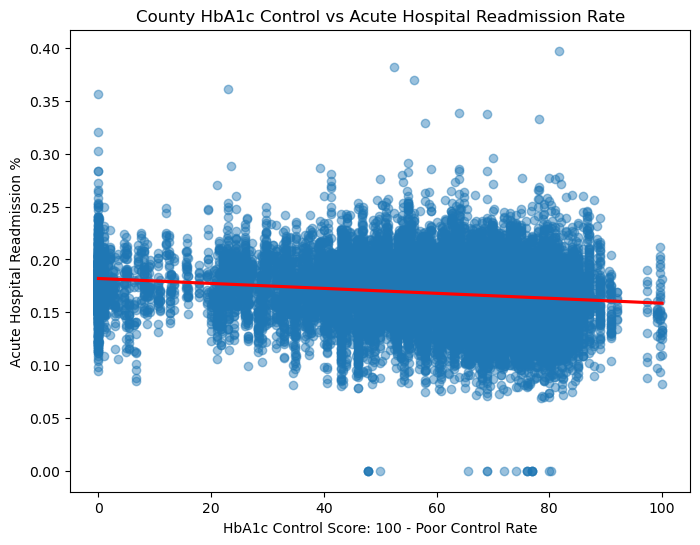

In [37]:
# 6. Scatterplot
plt.figure(figsize=(8, 6))

sns.regplot(
    data=hba1c_analysis,
    x="hba1c_control_score",
    y=readmission_col,
    scatter_kws={"alpha": 0.45},
    line_kws={"color": "red"}
)

plt.xlabel("HbA1c Control Score: 100 - Poor Control Rate")
plt.ylabel("Acute Hospital Readmission %")
plt.title("County HbA1c Control vs Acute Hospital Readmission Rate")
plt.show()

---
[Next: Unsupervised Learning &#8594;](03_unsupervised_learning.ipynb)